In [3]:
import pandas as pd
import numpy as np
import json

CSV_PATH = "us_airports - us_airports.csv"

df = pd.read_csv(CSV_PATH)
df.columns

Index(['OID', 'EFF_DATE', 'SITE_NO', 'SITE_TYPE_CODE', 'STATE_CODE', 'ARPT_ID',
       'ICAO_ID', 'ARPT_NAME', 'CITY', 'COUNTRY_CODE', 'OWNERSHIP_TYPE_CODE',
       'FACILITY_USE_CODE', 'RWYT1_ID', 'RWY1_ID', 'RWYT2_ID', 'RWY2_ID',
       'LAT1_DECIMAL', 'LONG1_DECIMAL', 'LAT2_DECIMAL', 'LONG2_DECIMAL',
       'ALT1_M', 'ALT2_M', 'HEAD1_DEG', 'HEAD2_DEG', 'TRAFFIC_PATTERN1',
       'TRAFFIC_PATTERN2', 'RWY_LEN', 'RWY_WIDTH', 'SURFACE_TYPE_CODE', 'COND',
       'TREATMENT_CODE', 'PCN', 'PAVEMENT_TYPE_CODE', 'SUBGRADE_STRENGTH_CODE',
       'TIRE_PRES_CODE', 'DTRM_METHOD_CODE', 'RWY_LGT_CODE', 'RWY_LEN_SOURCE',
       'LENGTH_SOURCE_DATE', 'GROSS_WT_SW', 'GROSS_WT_DW', 'GROSS_WT_DTW',
       'GROSS_WT_DDTW', 'Shape__Area', 'Shape__Length'],
      dtype='object')

In [4]:
# try to find a reasonable airport-name column automatically
name_candidates = [c for c in df.columns if c.upper() in ["ARPT_NAME", "AIRPORT_NAME", "NAME", "FACILITY_NAME"]]
if not name_candidates:
    name_candidates = [c for c in df.columns if "NAME" in c.upper()]  # fallback

NAME_COL = name_candidates[0] if name_candidates else None
NAME_COL

'ARPT_NAME'

In [5]:
airport_query = "Purdue"  # change this to whatever airport name you want
if NAME_COL is None:
    raise ValueError("Couldn't find an airport name column. Print df.columns and pick one manually.")

df_sel = df[df[NAME_COL].astype(str).str.contains(airport_query, case=False, na=False)].copy()
df_sel[[NAME_COL]].drop_duplicates().head(20)

,ARPT_NAME
2031,PURDUE UNIVERSITY


In [6]:
required_cols = ["LAT1_DECIMAL","LONG1_DECIMAL","LAT2_DECIMAL","LONG2_DECIMAL"]
missing = [c for c in required_cols if c not in df_sel.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_sel = df_sel.dropna(subset=required_cols).copy()
len(df_sel)

2

In [7]:
R = 6371000.0  # Earth radius in meters
FT_TO_M = 0.3048  # feet to meters
M_TO_FT = 1.0 / FT_TO_M  # meters to feet

def latlon_to_enu_m(lat, lon, lat0, lon0):
    lat = np.deg2rad(lat)
    lon = np.deg2rad(lon)
    lat0 = np.deg2rad(lat0)
    lon0 = np.deg2rad(lon0)

    E = (lon - lon0) * np.cos((lat + lat0) / 2.0) * R  # east offset in meters
    N = (lat - lat0) * R  # north offset in meters
    return E, N

def enu_to_latlon(E, N, lat0, lon0):
    lat0r = np.deg2rad(lat0)
    lon0r = np.deg2rad(lon0)

    lat = lat0r + (N / R)
    lon = lon0r + (E / (R * np.cos(lat0r)))
    return float(np.rad2deg(lat)), float(np.rad2deg(lon))

def runway_midpoint(lat1, lon1, lat2, lon2):
    return (lat1 + lat2) / 2.0, (lon1 + lon2) / 2.0

def compute_bearing_deg(lat1, lon1, lat2, lon2):
    lat1r = np.deg2rad(lat1)
    lat2r = np.deg2rad(lat2)
    dlon = np.deg2rad(lon2 - lon1)

    y = np.sin(dlon) * np.cos(lat2r)
    x = np.cos(lat1r) * np.sin(lat2r) - np.sin(lat1r) * np.cos(lat2r) * np.cos(dlon)

    bearing_deg = (np.rad2deg(np.arctan2(y, x)) + 360.0) % 360.0  # true bearing from point 1 to point 2
    return float(bearing_deg)

def heading_to_runway_number(heading_deg):
    runway_num = int(np.round(heading_deg / 10.0)) % 36  # runway numbers are heading/10 rounded
    if runway_num == 0:
        runway_num = 36
    return f"{runway_num:02d}"

def extract_runway_number(rwy_id):
    if pd.isna(rwy_id):
        return None
    s = str(rwy_id).strip().upper()
    digits = "".join(ch for ch in s if ch.isdigit())
    if len(digits) == 0:
        return None
    return digits[:2].zfill(2)

def point_in_polygon_xy(point_xy, poly_xy):
    x, y = point_xy
    inside = False
    n = len(poly_xy)

    for i in range(n):
        x1, y1 = poly_xy[i]
        x2, y2 = poly_xy[(i + 1) % n]

        crosses = ((y1 > y) != (y2 > y)) and (x < (x2 - x1) * (y - y1) / (y2 - y1 + 1e-12) + x1)
        if crosses:
            inside = not inside

    return inside

def build_runway_corridor_ft(lat1, lon1, lat2, lon2, half_width_ft=250.0, end_extend_ft=300.0):
    lat0, lon0 = runway_midpoint(lat1, lon1, lat2, lon2)  # midpoint as local reference

    x1, y1 = latlon_to_enu_m(lat1, lon1, lat0, lon0)
    x2, y2 = latlon_to_enu_m(lat2, lon2, lat0, lon0)

    dx = x2 - x1
    dy = y2 - y1
    length_m = float(np.hypot(dx, dy))
    if length_m == 0:
        return None

    ux = dx / length_m  # runway unit vector east component
    uy = dy / length_m  # runway unit vector north component

    nx = -uy  # perpendicular unit vector east component
    ny = ux   # perpendicular unit vector north component

    half_width_m = half_width_ft * FT_TO_M
    end_extend_m = end_extend_ft * FT_TO_M

    x1e = x1 - ux * end_extend_m
    y1e = y1 - uy * end_extend_m
    x2e = x2 + ux * end_extend_m
    y2e = y2 + uy * end_extend_m

    left1 = (x1e + nx * half_width_m, y1e + ny * half_width_m)
    left2 = (x2e + nx * half_width_m, y2e + ny * half_width_m)
    right2 = (x2e - nx * half_width_m, y2e - ny * half_width_m)
    right1 = (x1e - nx * half_width_m, y1e - ny * half_width_m)

    corners_xy = [left1, left2, right2, right1]
    corners_latlon = [enu_to_latlon(E, N, lat0, lon0) for E, N in corners_xy]

    heading_12_deg = compute_bearing_deg(lat1, lon1, lat2, lon2)  # heading from endpoint 1 to 2
    heading_21_deg = (heading_12_deg + 180.0) % 360.0  # reciprocal runway heading

    return {
        "lat0": lat0,
        "lon0": lon0,
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
        "ux": ux,
        "uy": uy,
        "nx": nx,
        "ny": ny,
        "length_m": length_m,
        "length_ft": length_m * M_TO_FT,
        "heading_12_deg": heading_12_deg,
        "heading_21_deg": heading_21_deg,
        "heading_12_runway_num": heading_to_runway_number(heading_12_deg),
        "heading_21_runway_num": heading_to_runway_number(heading_21_deg),
        "corners_xy": corners_xy,
        "corners_latlon": corners_latlon
    }

def runway_frame_to_xy(r_along_ft, c_cross_ft, corridor):
    r_m = r_along_ft * FT_TO_M  # along-runway displacement in meters
    c_m = c_cross_ft * FT_TO_M  # cross-track displacement in meters

    x = r_m * corridor["ux"] + c_m * corridor["nx"]  # rotate into east component
    y = r_m * corridor["uy"] + c_m * corridor["ny"]  # rotate into north component
    return x, y

def runway_frame_to_latlon(r_along_ft, c_cross_ft, corridor):
    x, y = runway_frame_to_xy(r_along_ft, c_cross_ft, corridor)
    return enu_to_latlon(x, y, corridor["lat0"], corridor["lon0"])

def point_in_corridor_latlon(uav_lat, uav_lon, corridor):
    x, y = latlon_to_enu_m(uav_lat, uav_lon, corridor["lat0"], corridor["lon0"])
    return point_in_polygon_xy((x, y), corridor["corners_xy"])

def project_point_to_runway_frame(uav_lat, uav_lon, corridor):
    x, y = latlon_to_enu_m(uav_lat, uav_lon, corridor["lat0"], corridor["lon0"])

    along_m = x * corridor["ux"] + y * corridor["uy"]  # projection onto runway axis
    cross_m = x * corridor["nx"] + y * corridor["ny"]  # projection onto perpendicular axis

    return along_m * M_TO_FT, cross_m * M_TO_FT

In [8]:
half_width_ft = 250.0  # corridor half-width in feet
end_extend_ft = 300.0  # extension beyond each runway end in feet

corridors = []
for _, r in df_sel.iterrows():
    corridor = build_runway_corridor_ft(
        r["LAT1_DECIMAL"],
        r["LONG1_DECIMAL"],
        r["LAT2_DECIMAL"],
        r["LONG2_DECIMAL"],
        half_width_ft=half_width_ft,
        end_extend_ft=end_extend_ft
    )

    if corridor is None:
        continue

    rwy1_num = extract_runway_number(r.get("RWY1_ID", None))
    rwy2_num = extract_runway_number(r.get("RWY2_ID", None))

    corridors.append({
        "airport_name": r.get(NAME_COL, None),
        "ARPT_ID": r.get("ARPT_ID", None),
        "RWY1_ID": r.get("RWY1_ID", None),
        "RWY2_ID": r.get("RWY2_ID", None),
        "RWY1_NUM_FROM_NAME": rwy1_num,
        "RWY2_NUM_FROM_NAME": rwy2_num,
        "computed_heading_12_deg": corridor["heading_12_deg"],
        "computed_heading_21_deg": corridor["heading_21_deg"],
        "computed_runway_num_12": corridor["heading_12_runway_num"],
        "computed_runway_num_21": corridor["heading_21_runway_num"],
        "runway_len_ft": corridor["length_ft"],
        "corridor_half_width_ft": half_width_ft,
        "corridor_end_extend_ft": end_extend_ft,
        "corridor_corners_latlon": corridor["corners_latlon"],
        "corridor_obj": corridor
    })

len(corridors), corridors[0] if corridors else None

(2,
 {'airport_name': 'PURDUE UNIVERSITY',
  'ARPT_ID': 'LAF',
  'RWY1_ID': '5',
  'RWY2_ID': '23',
  'RWY1_NUM_FROM_NAME': '05',
  'RWY2_NUM_FROM_NAME': '23',
  'computed_heading_12_deg': 49.409876915679774,
  'computed_heading_21_deg': 229.40987691567977,
  'computed_runway_num_12': '05',
  'computed_runway_num_21': '23',
  'runway_len_ft': 4220.866919522543,
  'corridor_half_width_ft': 250.0,
  'corridor_end_extend_ft': 300.0,
  'corridor_corners_latlon': [(40.408169572694284, -86.94042632726688),
   (40.416766930793905, -86.92724600876738),
   (40.41572608730572, -86.92607490544015),
   (40.40712872920609, -86.93925522393964)],
  'corridor_obj': {'lat0': 40.41194783,
   'lon0': -86.933250455,
   'x1': np.float64(-488.52208974413566),
   'y1': np.float64(-418.5010095651613),
   'x2': np.float64(488.4947680254693),
   'y2': np.float64(418.5010095637467),
   'ux': np.float64(0.759425953527451),
   'uy': np.float64(0.650593745058252),
   'nx': np.float64(-0.650593745058252),
   'ny': n

In [9]:
if not corridors:
    raise ValueError("No corridors were built. Check airport_query and runway endpoint columns.")

c0 = corridors[0]
corr = c0["corridor_obj"]

print("Airport:", c0["airport_name"])
print("Runway pair:", c0["RWY1_ID"], "/", c0["RWY2_ID"])
print("Computed heading 1->2:", round(c0["computed_heading_12_deg"], 2), "deg")
print("Computed heading 2->1:", round(c0["computed_heading_21_deg"], 2), "deg")
print("Computed runway numbers:", c0["computed_runway_num_12"], "/", c0["computed_runway_num_21"])

sim_points = [
    ("center of runway", 0.0, 0.0),
    ("inside, along runway", 500.0, 0.0),
    ("inside, slight right offset", 500.0, 0.5 * half_width_ft),
    ("near boundary", 500.0, 0.95 * half_width_ft),
    ("outside right boundary", 500.0, 1.10 * half_width_ft),
    ("outside left boundary", 500.0, -1.10 * half_width_ft),
    ("extended approach region", -0.8 * end_extend_ft, 0.0),
    ("past far threshold", c0["runway_len_ft"] / 2.0 + end_extend_ft + 100.0, 0.0)
]

sim_rows = []
for label, r_along_ft, c_cross_ft in sim_points:
    lat, lon = runway_frame_to_latlon(r_along_ft, c_cross_ft, corr)
    inside = point_in_corridor_latlon(lat, lon, corr)
    along_proj_ft, cross_proj_ft = project_point_to_runway_frame(lat, lon, corr)

    sim_rows.append({
        "test_case": label,
        "input_along_ft": round(r_along_ft, 2),
        "input_cross_ft": round(c_cross_ft, 2),
        "lat": lat,
        "lon": lon,
        "projected_along_ft": round(along_proj_ft, 2),
        "projected_cross_ft": round(cross_proj_ft, 2),
        "inside_corridor": inside
    })

sim_df = pd.DataFrame(sim_rows)
sim_df

Airport: PURDUE UNIVERSITY
Runway pair: 5 / 23
Computed heading 1->2: 49.41 deg
Computed heading 2->1: 229.41 deg
Computed runway numbers: 05 / 23


,test_case,input_along_ft,input_cross_ft,lat,lon,projected_along_ft,projected_cross_ft,inside_corridor
0,center of runway,0.00,0.0,40.411948,-86.933250,-0.00,0.00,True
1,"inside, along runway",500.00,0.0,40.412840,-86.931883,500.00,0.00,True
2,"inside, slight right offset",500.00,125.0,40.413100,-86.932176,500.00,125.00,True
3,near boundary,500.00,237.5,40.413334,-86.932440,500.00,237.50,True
4,outside right boundary,500.00,275.0,40.413412,-86.932528,500.00,275.00,False
5,outside left boundary,500.00,-275.0,40.412267,-86.931239,500.00,-275.00,False
6,extended approach region,-240.00,0.0,40.411520,-86.933907,-240.00,0.00,True
7,past far threshold,2510.43,0.0,40.416425,-86.926387,2510.39,0.04,False


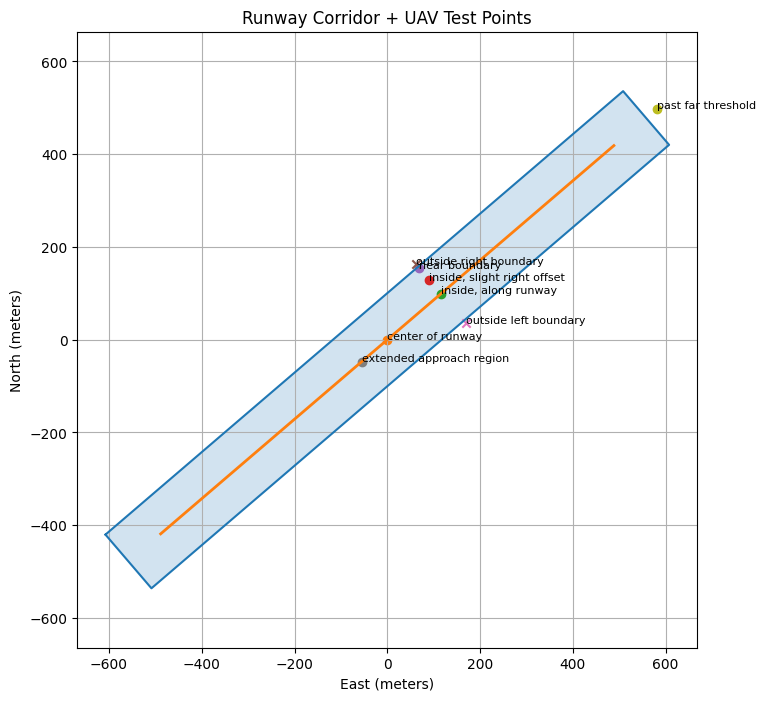

In [10]:
import matplotlib.pyplot as plt

# pick first corridor
if not corridors:
    raise ValueError("No corridors available")

c0 = corridors[0]
corr = c0["corridor_obj"]

# extract polygon in ENU for plotting
poly_xy = corr["corners_xy"] + [corr["corners_xy"][0]]  # close shape
px = [p[0] for p in poly_xy]
py = [p[1] for p in poly_xy]

# runway centerline
x1, y1 = corr["x1"], corr["y1"]
x2, y2 = corr["x2"], corr["y2"]

# reuse your sim points from before
plot_points = []
for label, r_along_ft, c_cross_ft in sim_points:
    x, y = runway_frame_to_xy(r_along_ft, c_cross_ft, corr)
    inside = abs(c_cross_ft) <= half_width_ft
    plot_points.append((label, x, y, inside))

# plot
plt.figure(figsize=(8,8))

# corridor polygon
plt.plot(px, py)
plt.fill(px, py, alpha=0.2)

# runway centerline
plt.plot([x1, x2], [y1, y2], linewidth=2)

# UAV points
for label, x, y, inside in plot_points:
    if inside:
        plt.scatter(x, y)
    else:
        plt.scatter(x, y, marker='x')
    plt.text(x, y, label, fontsize=8)

plt.xlabel("East (meters)")
plt.ylabel("North (meters)")
plt.title("Runway Corridor + UAV Test Points")
plt.axis('equal')
plt.grid()

plt.show()

In [13]:
import numpy as np

dt = 1.0
steps = 100

speed_ft_per_sec = 120.0

wind_std_dev = 3.0          # random wind (ft per step)
correction_gain = 0.08      # how strongly UAV corrects itself

r_along = -300.0
c_cross = 0.0

positions = []

for t in range(steps):
    # forward motion
    r_along += speed_ft_per_sec * dt

    # wind disturbance (random)
    wind = np.random.normal(0, wind_std_dev)

    # autopilot correction (pull back toward centerline)
    correction = -correction_gain * c_cross

    # update lateral position
    c_cross += wind + correction

    lat, lon = runway_frame_to_latlon(r_along, c_cross, corr)

    inside = point_in_corridor_latlon(lat, lon, corr)

    positions.append((t, r_along, c_cross, lat, lon, inside))

sim_time_df = pd.DataFrame(positions, columns=[
    "time_s", "along_ft", "cross_ft", "lat", "lon", "inside"
])

sim_time_df.head()

,time_s,along_ft,cross_ft,lat,lon,inside
0,0,-180.0,0.074311,40.411627,-86.933743,True
1,1,-60.0,1.706951,40.411844,-86.933418,True
2,2,60.0,-2.729728,40.412049,-86.933080,True
3,3,180.0,4.549856,40.412278,-86.932769,True
4,4,300.0,4.537948,40.412492,-86.932441,True


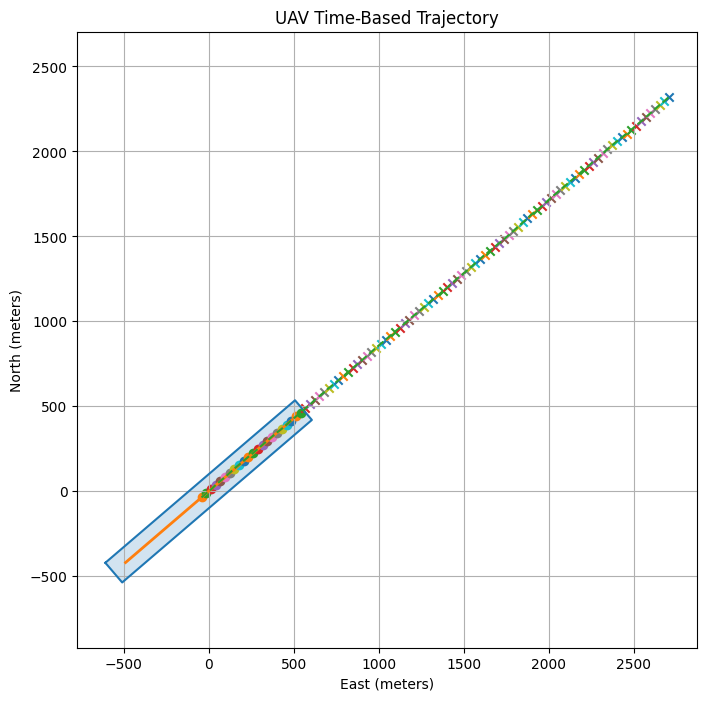

In [14]:
# convert trajectory to ENU for plotting
traj_x = []
traj_y = []
colors = []

for _, row in sim_time_df.iterrows():
    x, y = runway_frame_to_xy(row["along_ft"], row["cross_ft"], corr)
    traj_x.append(x)
    traj_y.append(y)
    colors.append(row["inside"])

plt.figure(figsize=(8,8))

# corridor
plt.plot(px, py)
plt.fill(px, py, alpha=0.2)

# runway
plt.plot([x1, x2], [y1, y2], linewidth=2)

# trajectory
for i in range(len(traj_x)):
    if colors[i]:
        plt.scatter(traj_x[i], traj_y[i])
    else:
        plt.scatter(traj_x[i], traj_y[i], marker='x')

plt.plot(traj_x, traj_y, linestyle='--')

plt.title("UAV Time-Based Trajectory")
plt.xlabel("East (meters)")
plt.ylabel("North (meters)")
plt.axis('equal')
plt.grid()

plt.show()